In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib

# Reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [4]:
file_path = "data/job_postings_monthly.xlsx"
xls = pd.ExcelFile(file_path)

df_list = []
for sheet in xls.sheet_names:
    month_df = pd.read_excel(xls, sheet_name=sheet)
    df_list.append(month_df)

df_all = pd.concat(df_list, ignore_index=True)
print(f"Total rows: {len(df_all)}")

Total rows: 478895


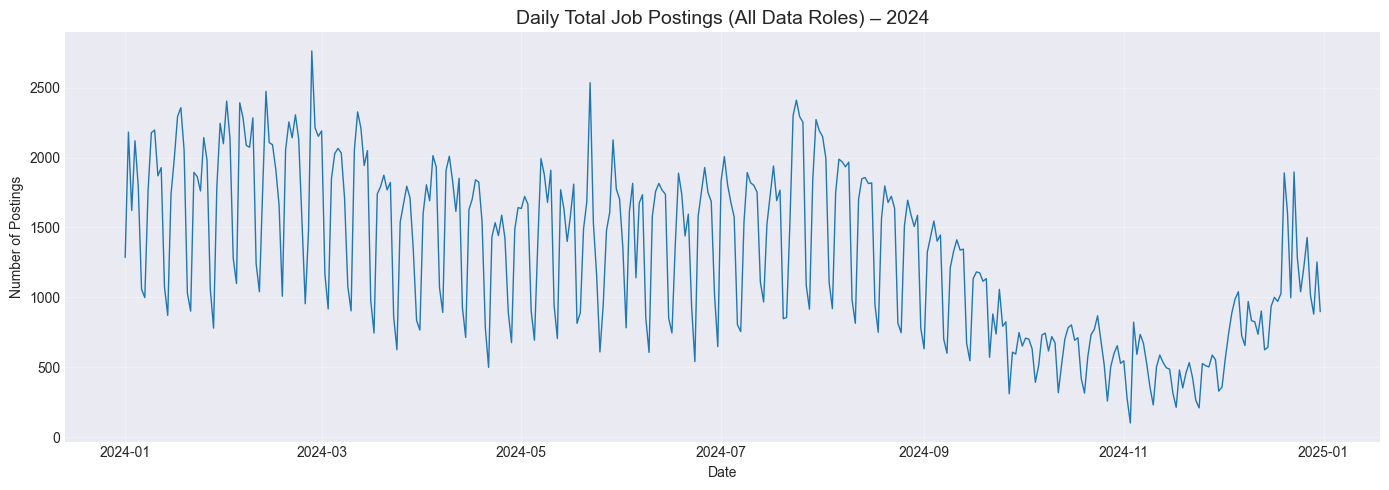

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

# style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Ensure date column is datetime
df_all["job_posted_date"] = pd.to_datetime(df_all["job_posted_date"])

# Daily total job postings over the year (all roles combined)
daily_total = df_all.groupby(df_all["job_posted_date"].dt.date).size()
daily_total.index = pd.to_datetime(daily_total.index)

plt.figure(figsize=(14,5))
plt.plot(daily_total.index, daily_total.values, linewidth=1, color='#1f77b4')
plt.title("Daily Total Job Postings (All Data Roles) – 2024", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Postings")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

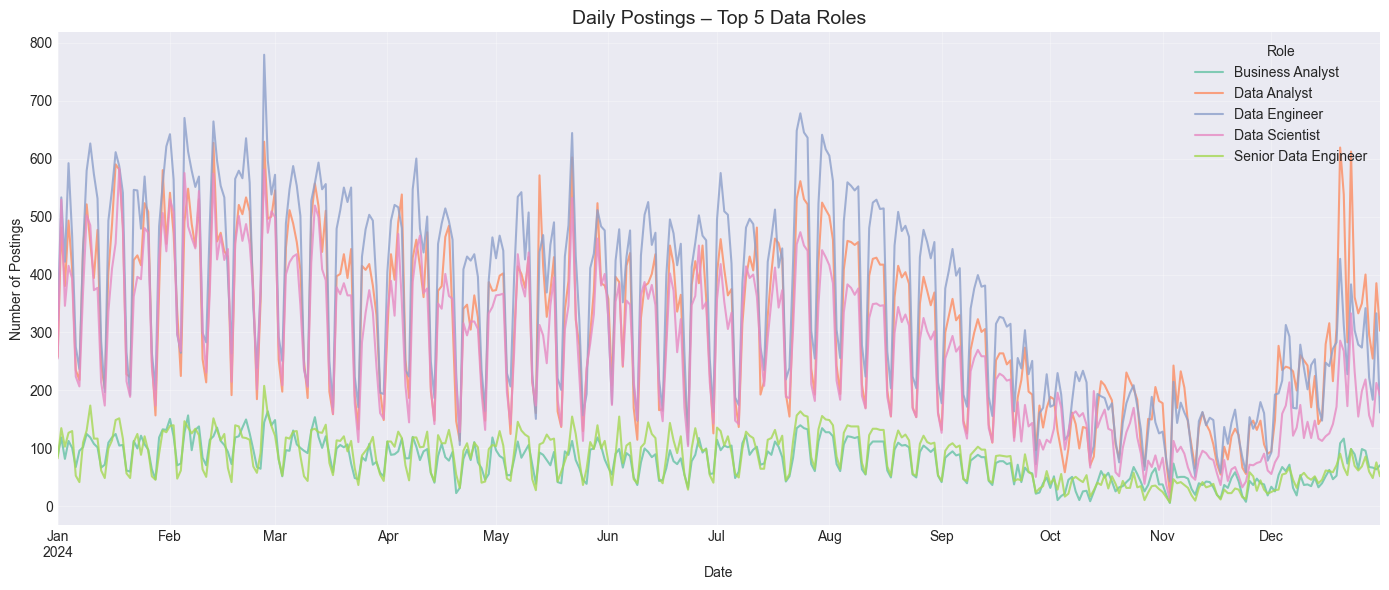

In [6]:
# -------------------------------------------------------------------
# Daily postings by role (top 5 roles – avoid clutter)
# -------------------------------------------------------------------
top_roles = df_all["job_title_short"].value_counts().head(5).index
df_top = df_all[df_all["job_title_short"].isin(top_roles)]
daily_by_role = df_top.groupby([df_top["job_posted_date"].dt.date, "job_title_short"]).size().unstack(fill_value=0)
daily_by_role.index = pd.to_datetime(daily_by_role.index)

plt.figure(figsize=(14,6))
daily_by_role.plot(ax=plt.gca(), linewidth=1.5, alpha=0.8)
plt.title("Daily Postings – Top 5 Data Roles", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Postings")
plt.legend(title="Role")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

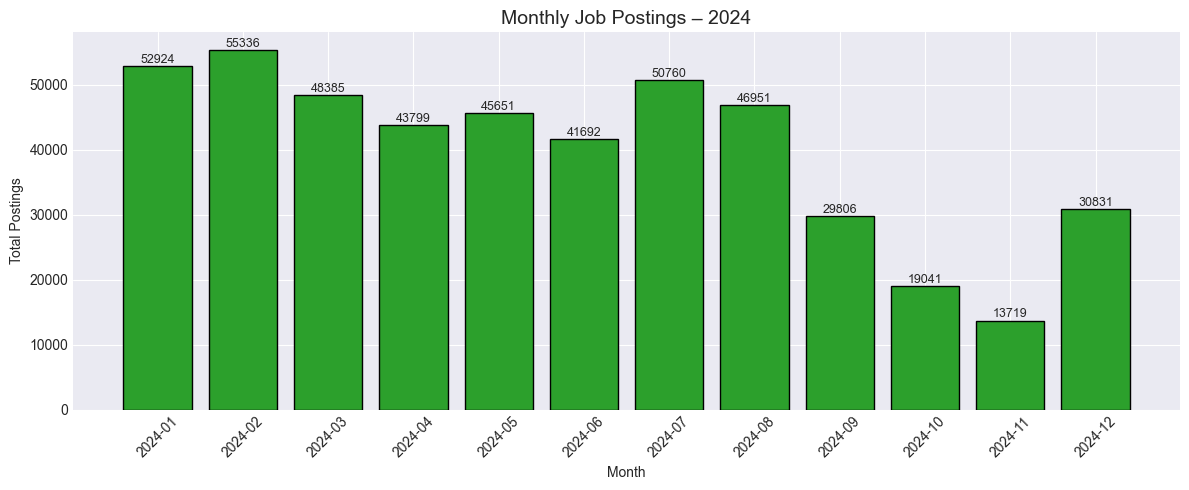

In [7]:

#Monthly total postings (bar chart)
df_all["year_month"] = df_all["job_posted_date"].dt.to_period("M")
monthly = df_all.groupby("year_month").size()
months = monthly.index.astype(str)

plt.figure(figsize=(12,5))
plt.bar(months, monthly.values, color='#2ca02c', edgecolor='black')
plt.title("Monthly Job Postings – 2024", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Postings")
plt.xticks(rotation=45)
for i, v in enumerate(monthly.values):
    plt.text(i, v + 500, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\mynse\AppData\Local\Temp\ipykernel_22284\2833760669.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_by_weekday.index, y=avg_by_weekday.values, order=weekday_order, palette="Blues_d")


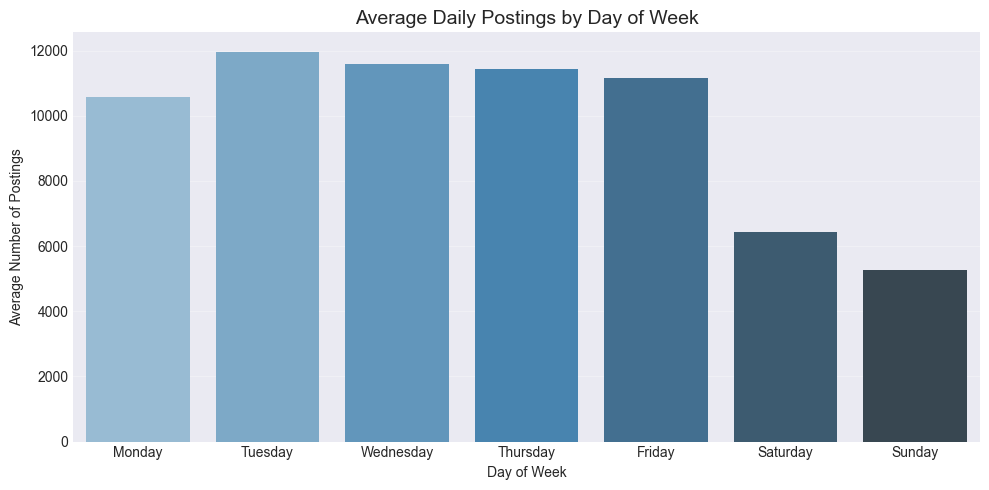

In [8]:
# Day-of-week pattern (average postings per weekday)
df_all["weekday"] = df_all["job_posted_date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_by_weekday = df_all.groupby("weekday").size() / len(df_all["weekday"].unique())  # average per weekday

plt.figure(figsize=(10,5))
sns.barplot(x=avg_by_weekday.index, y=avg_by_weekday.values, order=weekday_order, palette="Blues_d")
plt.title("Average Daily Postings by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Number of Postings")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\mynse\AppData\Local\Temp\ipykernel_22284\1580743332.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=country_counts.index, x=country_counts.values, palette="viridis")


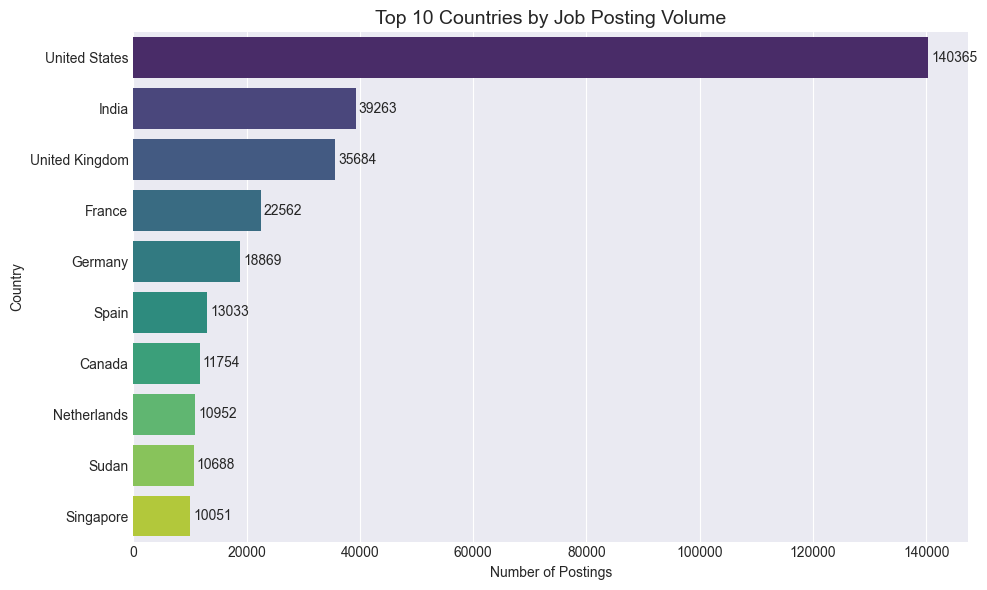

In [9]:
# Top 10 countries by number of postings
country_counts = df_all["job_country"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(y=country_counts.index, x=country_counts.values, palette="viridis")
plt.title("Top 10 Countries by Job Posting Volume", fontsize=14)
plt.xlabel("Number of Postings")
plt.ylabel("Country")
for i, v in enumerate(country_counts.values):
    plt.text(v + 500, i, str(v), va='center')
plt.tight_layout()
plt.show()

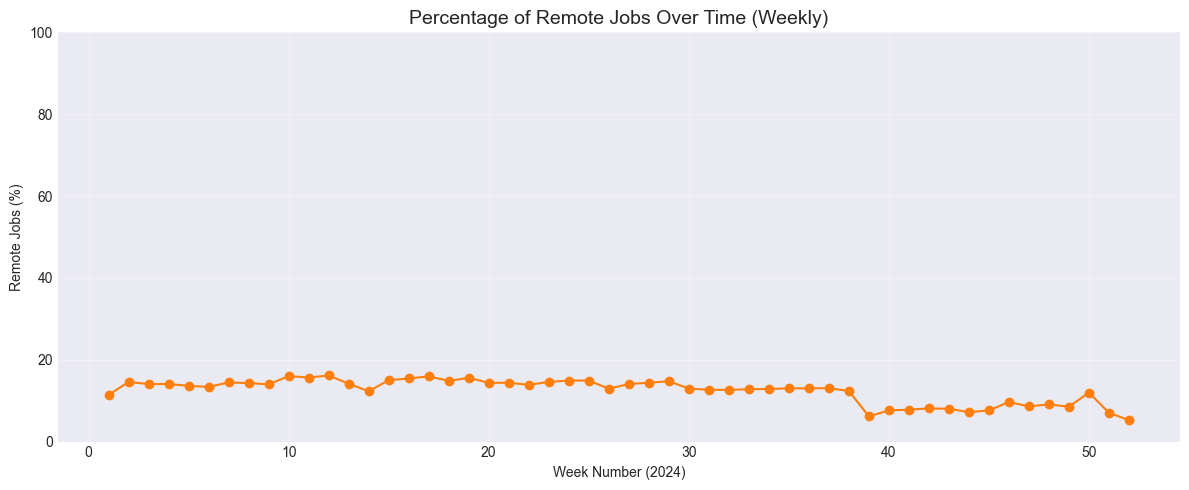

In [10]:
# Remote work trend over time (percentage of remote jobs per week)
df_all["week"] = df_all["job_posted_date"].dt.isocalendar().week
weekly_remote = df_all.groupby("week")["job_work_from_home"].mean() * 100

plt.figure(figsize=(12,5))
plt.plot(weekly_remote.index, weekly_remote.values, marker='o', linestyle='-', color='#ff7f0e')
plt.title("Percentage of Remote Jobs Over Time (Weekly)", fontsize=14)
plt.xlabel("Week Number (2024)")
plt.ylabel("Remote Jobs (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\mynse\AppData\Local\Temp\ipykernel_22284\1595098490.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=list(skills), x=list(counts), palette="rocket")


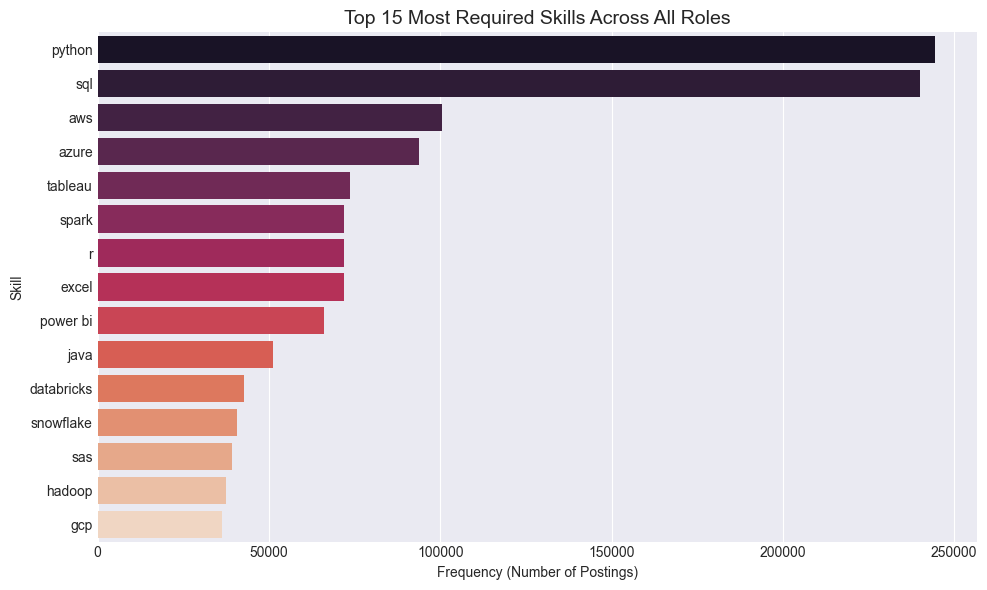

In [11]:
# Top 15 most required skills (overall)
# Parse job_skills column (string representation of list)
def parse_skills(skill_str):
    if pd.isna(skill_str):
        return []
    try:
        return ast.literal_eval(skill_str)
    except:
        return []

df_all["skills_list"] = df_all["job_skills"].apply(parse_skills)
all_skills = [skill for sublist in df_all["skills_list"] for skill in sublist]
skill_counts = Counter(all_skills).most_common(15)
skills, counts = zip(*skill_counts)

plt.figure(figsize=(10,6))
sns.barplot(y=list(skills), x=list(counts), palette="rocket")
plt.title("Top 15 Most Required Skills Across All Roles", fontsize=14)
plt.xlabel("Frequency (Number of Postings)")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

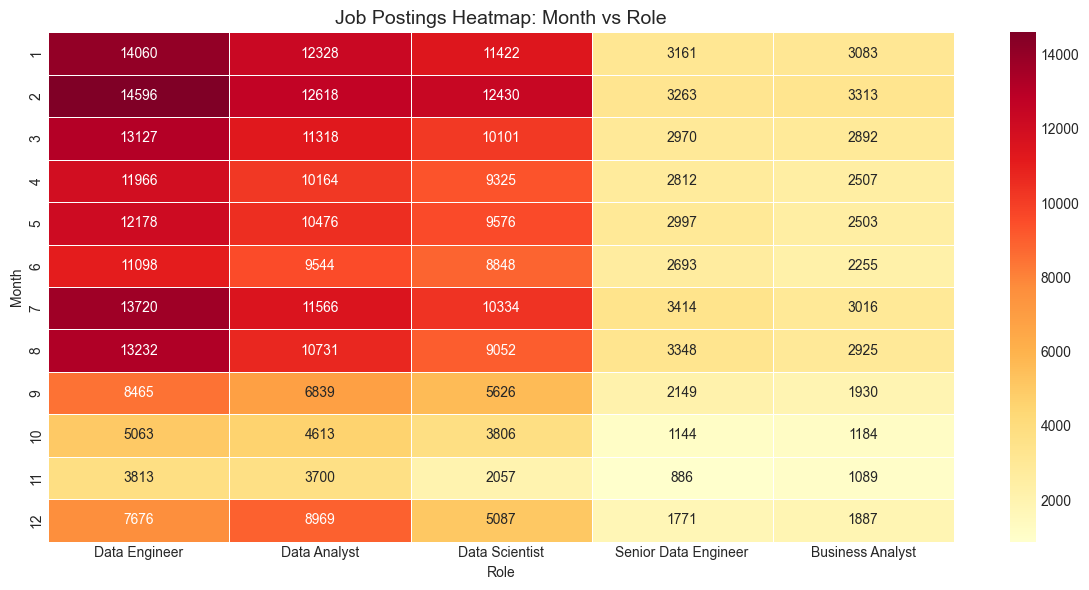

In [12]:
# Heatmap: Posting volume by month and role (for top 5 roles)
df_all["month"] = df_all["job_posted_date"].dt.month
month_role = df_all.groupby(["month", "job_title_short"]).size().unstack(fill_value=0)
month_role = month_role[top_roles]  # keep only top 5 roles

plt.figure(figsize=(12,6))
sns.heatmap(month_role, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
plt.title("Job Postings Heatmap: Month vs Role", fontsize=14)
plt.xlabel("Role")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

In [13]:
# Optional: Save all plots as high-res images
# Uncomment to save each plot to a folder
# import os
# os.makedirs("eda_plots", exist_ok=True)
# plt.figure(1).savefig("eda_plots/daily_total.png", dpi=150)
# plt.figure(2).savefig("eda_plots/daily_by_role.png", dpi=150)
# ... etc.

In [14]:
def prepare_daily_demand(df, role):
    """Filter role, aggregate daily demand, fill missing days with 0."""
    role_df = df[df["job_title_short"] == role].copy()
    role_df["job_posted_date"] = pd.to_datetime(role_df["job_posted_date"])
    
    daily = role_df.groupby(role_df["job_posted_date"].dt.date).size()
    daily = daily.reset_index(name="demand")
    daily.columns = ["date", "demand"]
    
    full_range = pd.date_range(start="2024-01-01", end="2024-12-31", freq="D")
    daily = daily.set_index("date").reindex(full_range, fill_value=0)
    daily.index.name = "date"
    daily = daily.reset_index()
    daily.columns = ["date", "demand"]
    return daily

def create_sequences(data, lookback):
    """
    Create sliding windows.
    data: 1D numpy array (scaled)
    lookback: number of past days to use as input
    Returns X (samples, lookback) and y (samples,)
    """
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

def train_lstm_for_role(role, lookback=7, epochs=50, batch_size=32, patience=5):
    """
    Train a stateless LSTM with shuffle=True.
    Saves model and scaler.
    Returns history and test MAPE.
    """
    import os
    print(f"\n{'='*50}")
    print(f"Training LSTM for role: {role}")
    print(f"{'='*50}")
    
    # 1. Daily demand
    daily = prepare_daily_demand(df_all, role)
    demand = daily["demand"].values.astype(np.float32)
    
    # 2. Scale to [0,1]
    scaler = MinMaxScaler(feature_range=(0,1))
    demand_scaled = scaler.fit_transform(demand.reshape(-1,1)).flatten()
    
    # 3. Create sequences (sliding windows)
    X, y = create_sequences(demand_scaled, lookback)
    print(f"Total sequences: {len(X)}")
    
    # 4. Chronological split (80% train, 10% val, 10% test)
    train_end = int(0.8 * len(X))
    val_end = int(0.9 * len(X))
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    
    # 5. Reshape for LSTM: (samples, lookback, features=1)
    X_train = X_train.reshape(-1, lookback, 1)
    X_val = X_val.reshape(-1, lookback, 1)
    X_test = X_test.reshape(-1, lookback, 1)
    
    # 6. Build stateless LSTM model
    model = Sequential([
        LSTM(100, activation='tanh', input_shape=(lookback, 1)),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.summary()
    
    # 7. Train
    early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,          # <-- Shuffles sequence order, not internal time steps
        callbacks=[early_stop],
        verbose=1
    )
    
    # 8. Evaluate on test set
    y_pred_scaled = model.predict(X_test).flatten()
    y_true_scaled = y_test
    
    # Inverse transform
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1,1)).flatten()
    
    # MAPE (ignore zero true values)
    def mape(y_true, y_pred):
        mask = y_true != 0
        if np.sum(mask) == 0:
            return np.nan
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    test_mape = mape(y_true, y_pred)
    print(f"\nTest MAPE: {test_mape:.2f}%")
    
    # 9. Save model and scaler
    safe_role = role.replace(" ", "_")
    models_folder = "models"
    model.save(os.path.join(models_folder, f"lstm_{safe_role}.keras"))
    joblib.dump(scaler, os.path.join(models_folder, f"scaler_{safe_role}.pkl"))
    print(f"Saved: lstm_{safe_role}.keras and scaler_{safe_role}.pkl")
    
    # 10. Plot training loss
    plt.figure(figsize=(10,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{role} – Training Loss (MSE)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 11. Plot test predictions
    plt.figure(figsize=(12,4))
    plt.plot(y_true, label='True Demand', color='blue')
    plt.plot(y_pred, label='Predicted Demand', color='red', alpha=0.7)
    plt.title(f'{role} – Test Set Predictions (last 10% of days)')
    plt.xlabel('Test Sample Index')
    plt.ylabel('Number of Postings')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return history, test_mape


Training LSTM for role: Data Analyst
Total sequences: 352
Train: (281, 14), Val: (35, 14), Test: (36, 14)


c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0896 - mae: 0.2318 - val_loss: 0.0162 - val_mae: 0.1047
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0424 - mae: 0.1671 - val_loss: 0.0172 - val_mae: 0.1077
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0400 - mae: 0.1634 - val_loss: 0.0143 - val_mae: 0.0979
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0411 - mae: 0.1653 - val_loss: 0.0147 - val_mae: 0.0993
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0400 - mae: 0.1625 - val_loss: 0.0136 - val_mae: 0.0954
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0400 - mae: 0.1625 - val_loss: 0.0126 - val_mae: 0.0912
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0403 - mae: 0.1639 - val_loss: 0.0110 - val_mae: 0.0849
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0376 - mae: 0.1566 - val_loss: 0.0104 - val_mae: 0.0823
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0382 - mae: 

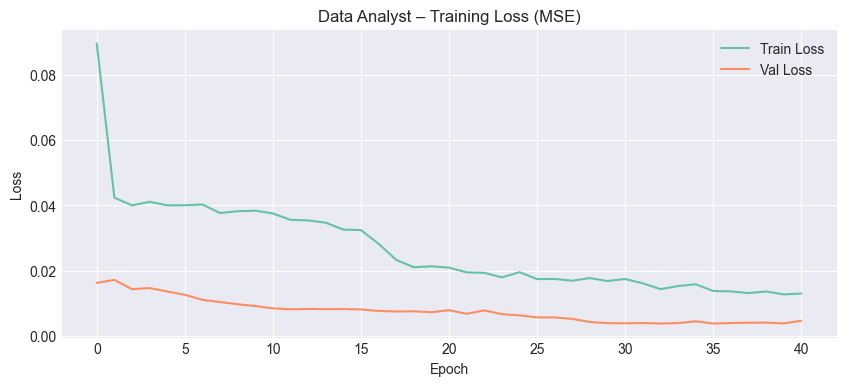

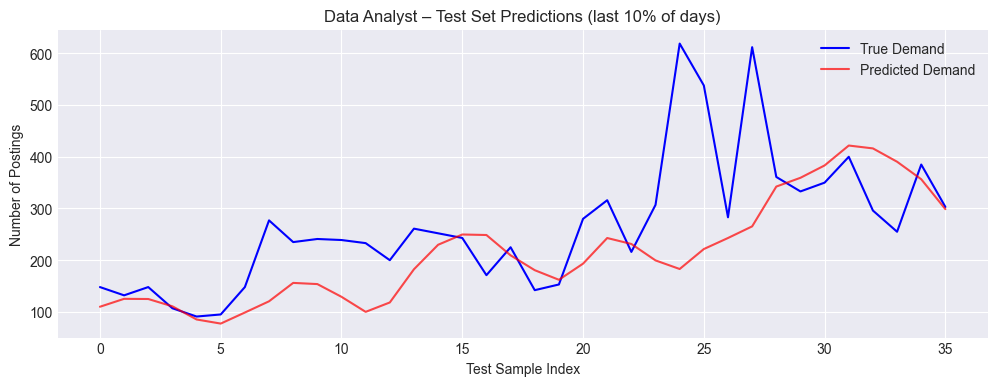

Final MAPE for Data Analyst: 25.90%


In [15]:
role = "Data Analyst"
history, mape_score = train_lstm_for_role(role, lookback=14, epochs=50, batch_size=8, patience=5)
print(f"Final MAPE for {role}: {mape_score:.2f}%")


Training LSTM for role: Business Analyst


Total sequences: 352
Train: (281, 14), Val: (35, 14), Test: (36, 14)


c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0670 - mae: 0.1991 - val_loss: 0.0163 - val_mae: 0.1007
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0304 - mae: 0.1424 - val_loss: 0.0161 - val_mae: 0.0998
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0292 - mae: 0.1400 - val_loss: 0.0144 - val_mae: 0.0931
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0289 - mae: 0.1377 - val_loss: 0.0135 - val_mae: 0.0903
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0295 - mae: 0.1394 - val_loss: 0.0127 - val_mae: 0.0882
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0292 - mae: 0.1384 - val_loss: 0.0127 - val_mae: 0.0881
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0296 - mae: 0.1393 - val_loss: 0.0119 - val_mae: 0.0859
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0287 - mae: 0.1382 - val_loss: 0.0122 - val_mae: 0.0867
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0297 - mae: 

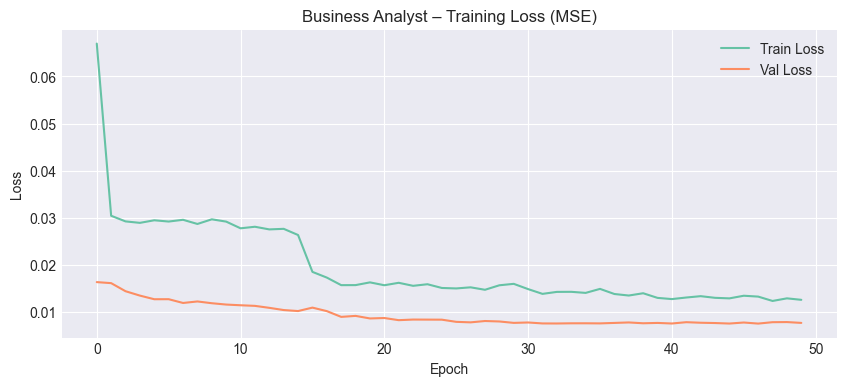

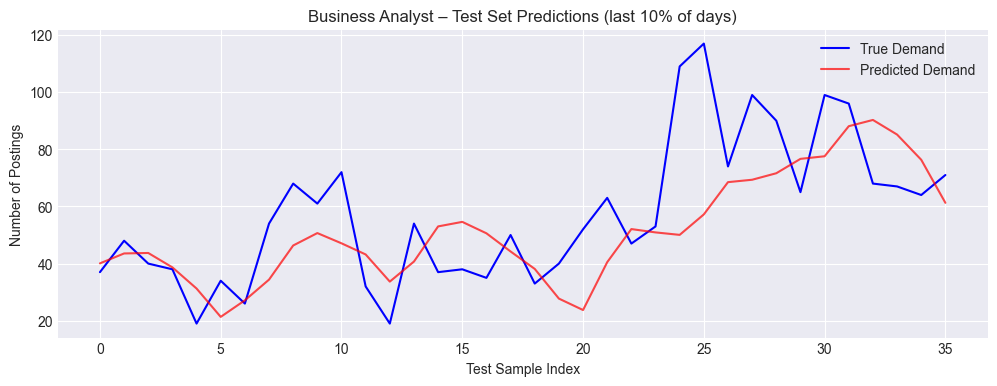

Final MAPE for Business Analyst: 27.48%


In [16]:
role = "Business Analyst"
history, mape_score = train_lstm_for_role(role, lookback=14, epochs=50, batch_size=8, patience=10)
print(f"Final MAPE for {role}: {mape_score:.2f}%")


Training LSTM for role: Software Engineer
Total sequences: 254
Train: (203, 112), Val: (25, 112), Test: (26, 112)


c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.1109 - mae: 0.2788 - val_loss: 0.0109 - val_mae: 0.0942
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0292 - mae: 0.1366 - val_loss: 0.0130 - val_mae: 0.1036
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0273 - mae: 0.1314 - val_loss: 0.0080 - val_mae: 0.0795
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0257 - mae: 0.1305 - val_loss: 0.0100 - val_mae: 0.0904
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0242 - mae: 0.1233 - val_loss: 0.0118 - val_mae: 0.0990
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0243 - mae: 0.1230 - val_loss: 0.0094 - val_mae: 0.0874
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0231 - mae: 0.1218 - val_loss: 0.0088 - val_mae: 0.0846
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0232 - mae: 0.1220 - val_loss: 0.0094 - val_mae: 0.0878
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

Test MAPE: 28.67%
Saved: lstm_Software_E

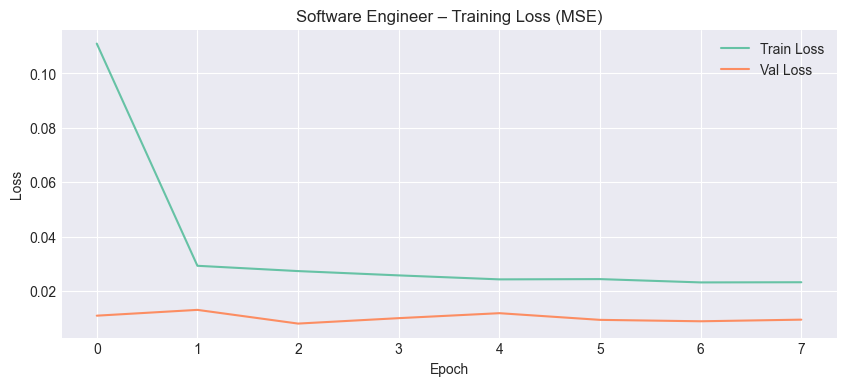

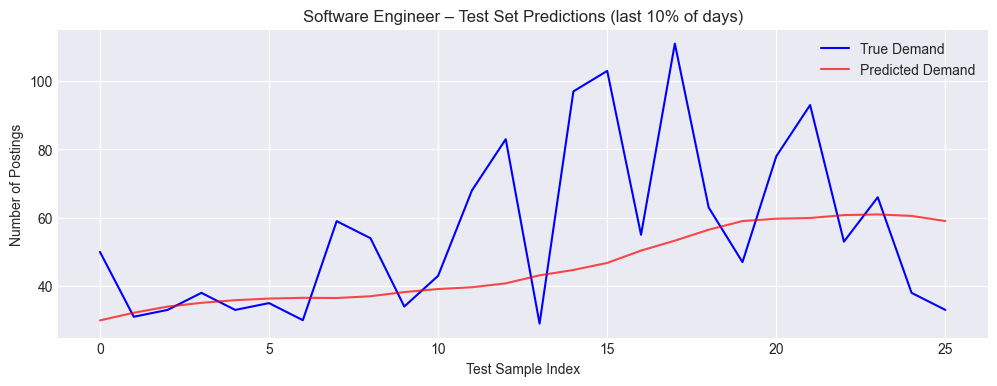

Final MAPE for Software Engineer: 28.67%


In [17]:
role = "Software Engineer"
history, mape_score = train_lstm_for_role(role, lookback=112, epochs=50, batch_size=32, patience=5)
print(f"Final MAPE for {role}: {mape_score:.2f}%")


Training LSTM for role: Cloud Engineer
Total sequences: 338
Train: (270, 28), Val: (34, 28), Test: (34, 28)


c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0368 - mae: 0.1473 - val_loss: 0.0064 - val_mae: 0.0655
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0161 - mae: 0.0976 - val_loss: 0.0114 - val_mae: 0.0941
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0159 - mae: 0.0967 - val_loss: 0.0090 - val_mae: 0.0817
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0164 - mae: 0.0996 - val_loss: 0.0082 - val_mae: 0.0776
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0157 - mae: 0.0964 - val_loss: 0.0087 - val_mae: 0.0803
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0158 - mae: 0.0968 - val_loss: 0.0088 - val_mae: 0.0810
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

Test MAPE: 36.34%
Saved: lstm_Cloud_Engineer.keras and scaler_Cloud_Engineer.pkl


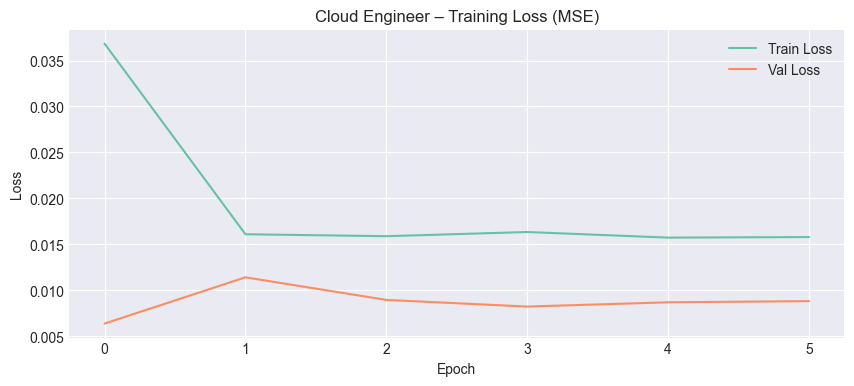

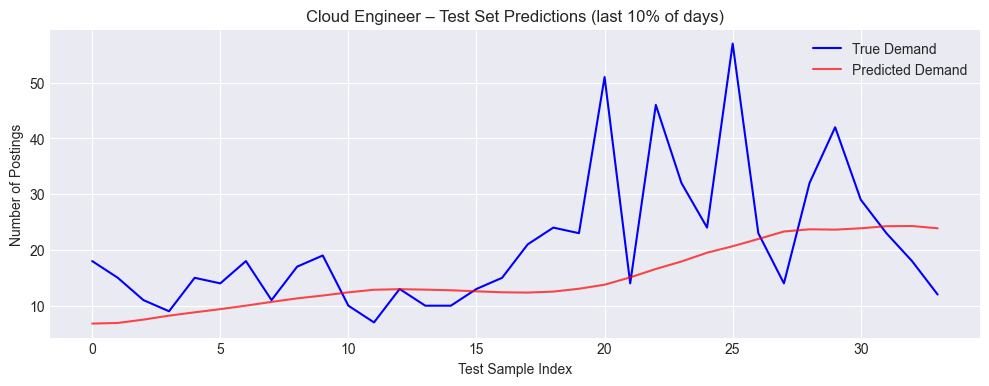

Final MAPE for Cloud Engineer: 36.34%


In [18]:
role = "Cloud Engineer"
history, mape_score = train_lstm_for_role(role, lookback=28, epochs=50, batch_size=16, patience=5)
print(f"Final MAPE for {role}: {mape_score:.2f}%")


Training LSTM for role: Machine Learning Engineer
Total sequences: 254
Train: (203, 112), Val: (25, 112), Test: (26, 112)


c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0789 - mae: 0.2182 - val_loss: 0.0082 - val_mae: 0.0740
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0276 - mae: 0.1364 - val_loss: 0.0091 - val_mae: 0.0782
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0228 - mae: 0.1201 - val_loss: 0.0090 - val_mae: 0.0778
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0221 - mae: 0.1218 - val_loss: 0.0085 - val_mae: 0.0752
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0213 - mae: 0.1165 - val_loss: 0.0074 - val_mae: 0.0699
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0205 - mae: 0.1144 - val_loss: 0.0066 - val_mae: 0.0666
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0206 - mae: 0.1153 - val_loss: 0.0065 - val_mae: 0.0661
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0210 - mae: 0.1147 - val_loss: 0.0059 - val_mae: 0.0636
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.019

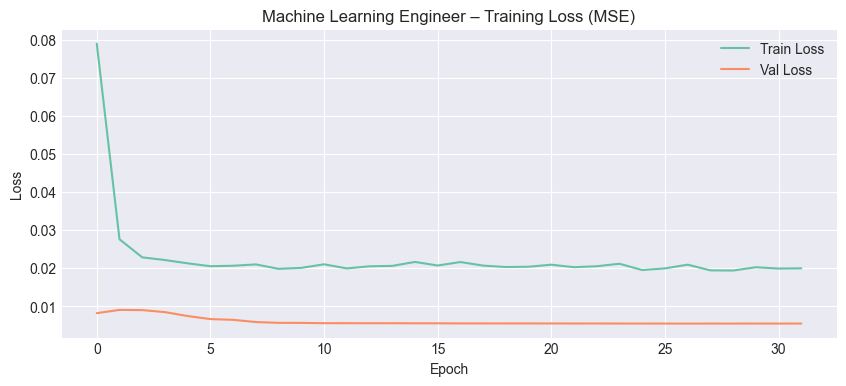

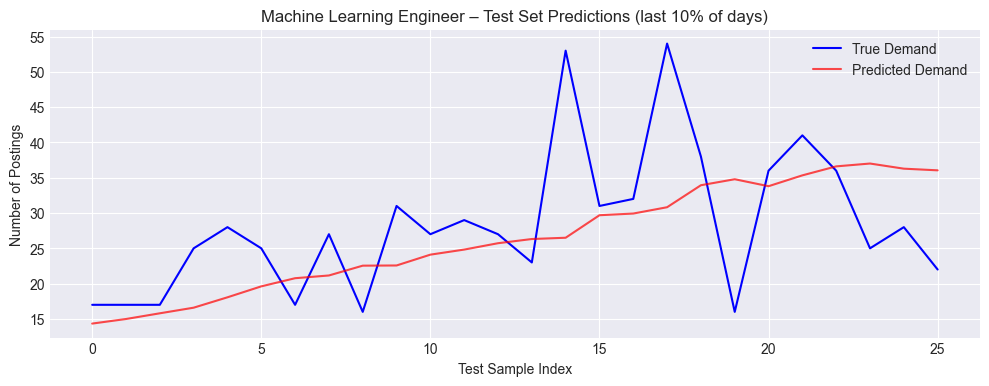

Final MAPE for Machine Learning Engineer: 26.01%


In [19]:
role = "Machine Learning Engineer"
history, mape_score = train_lstm_for_role(role, lookback=112, epochs=50, batch_size=16, patience=5)
print(f"Final MAPE for {role}: {mape_score:.2f}%")


Training LSTM for role: Data Scientist


Total sequences: 254
Train: (203, 112), Val: (25, 112), Test: (26, 112)


c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0715 - mae: 0.2149 - val_loss: 0.0142 - val_mae: 0.1138
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0329 - mae: 0.1444 - val_loss: 0.0036 - val_mae: 0.0471
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0278 - mae: 0.1396 - val_loss: 0.0036 - val_mae: 0.0476
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0233 - mae: 0.1269 - val_loss: 0.0061 - val_mae: 0.0713
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0238 - mae: 0.1214 - val_loss: 0.0052 - val_mae: 0.0647
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0249 - mae: 0.1284 - val_loss: 0.0038 - val_mae: 0.0492
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0237 - mae: 0.1260 - val_loss: 0.0037 - val_mae: 0.0487
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

Test MAPE: 20.04%
Saved: lstm_Data_Scientist.keras and scaler_Data_Scientist.pkl


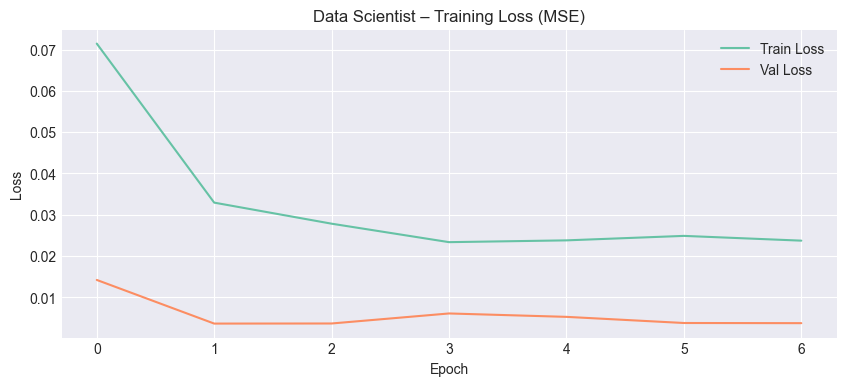

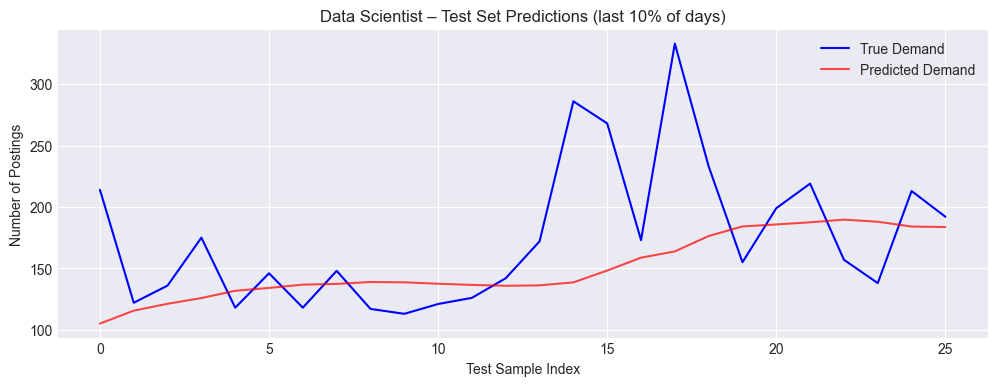

Final MAPE for Data Scientist: 20.04%


In [20]:
role = "Data Scientist"
history, mape_score = train_lstm_for_role(role, lookback=112, epochs=50, batch_size=32, patience=5)
print(f"Final MAPE for {role}: {mape_score:.2f}%")


Training LSTM for role: Data Engineer


Total sequences: 254
Train: (203, 112), Val: (25, 112), Test: (26, 112)


c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.1085 - mae: 0.2708 - val_loss: 0.0139 - val_mae: 0.1037
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0381 - mae: 0.1519 - val_loss: 0.0060 - val_mae: 0.0593
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0308 - mae: 0.1501 - val_loss: 0.0055 - val_mae: 0.0549
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0276 - mae: 0.1410 - val_loss: 0.0076 - val_mae: 0.0704
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0278 - mae: 0.1332 - val_loss: 0.0078 - val_mae: 0.0715
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0282 - mae: 0.1366 - val_loss: 0.0060 - val_mae: 0.0587
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0284 - mae: 0.1403 - val_loss: 0.0058 - val_mae: 0.0572
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0264 - mae: 0.1329 - val_loss: 0.0060 - val_mae: 0.0589
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

Test MAPE: 22.97%
Saved: lstm_Data_Engin

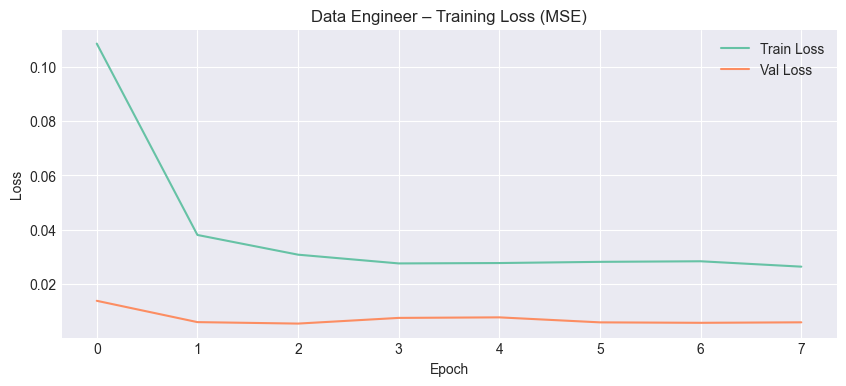

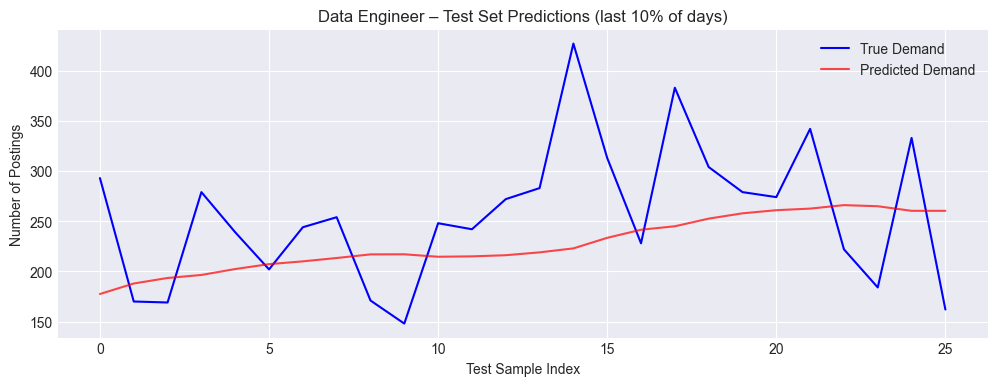

Final MAPE for Data Engineer: 22.97%


In [21]:
role = "Data Engineer"
history, mape_score = train_lstm_for_role(role, lookback=112, epochs=50, batch_size=32, patience=5)
print(f"Final MAPE for {role}: {mape_score:.2f}%")

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import tensorflow as tf

# Reproducibility 
np.random.seed(42)
tf.random.set_seed(42)

# Load data (assumes df_all already exists, else load it)
# If df_all is not in memory, uncomment these lines:
# file_path = "job_postings_monthly.xlsx"
# xls = pd.ExcelFile(file_path)
# df_list = [pd.read_excel(xls, sheet_name=s) for s in xls.sheet_names]
# df_all = pd.concat(df_list, ignore_index=True)
def train_and_save_role(role, lookback, batch_size, patience=5, epochs=50):
    """Train a single role and save model & scaler to models/ folder."""
    print(f"\n{'='*50}")
    print(f"Training {role} | lookback={lookback} | batch={batch_size}")
    print(f"{'='*50}")
    
    daily = prepare_daily_demand(df_all, role)
    demand = daily["demand"].values.astype(np.float32)
    
    scaler = MinMaxScaler(feature_range=(0,1))
    demand_scaled = scaler.fit_transform(demand.reshape(-1,1)).flatten()
    
    X, y = create_sequences(demand_scaled, lookback)
    
    train_end = int(0.8 * len(X))
    val_end = int(0.9 * len(X))
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    X_train = X_train.reshape(-1, lookback, 1)
    X_val = X_val.reshape(-1, lookback, 1)
    X_test = X_test.reshape(-1, lookback, 1)
    
    model = Sequential([
        LSTM(100, activation='tanh', input_shape=(lookback, 1)),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Evaluate on test set
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
    y_true = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
    
    def mape(y_true, y_pred):
        mask = y_true != 0
        if np.sum(mask) == 0:
            return np.nan
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    test_mape = mape(y_true, y_pred)
    print(f"Test MAPE: {test_mape:.2f}%")
    
    # Save model and scaler
    os.makedirs("models", exist_ok=True)
    safe_role = role.replace(" ", "_")
    model.save(os.path.join("models", f"lstm_{safe_role}.keras"))
    joblib.dump(scaler, os.path.join("models", f"scaler_{safe_role}.pkl"))
    print(f"Saved: models/lstm_{safe_role}.keras and models/scaler_{safe_role}.pkl")
    
    return history, test_mape

# Define the hyperparameters you used (from your training cells)
configs = [
    ("Data Analyst",           14,   8,  5),
    ("Business Analyst",       14,   8, 10),
    ("Software Engineer",     112,  32,  5),
    ("Cloud Engineer",         28,  16,  5),
    ("Machine Learning Engineer", 112, 16,  5),
    ("Data Scientist",        112,  32,  5),
    ("Data Engineer",         112,  32,  5),
]

# Train and save all
results = []
for role, lb, bs, pat in configs:
    _, mape = train_and_save_role(role, lookback=lb, batch_size=bs, patience=pat, epochs=50)
    results.append({"Role": role, "Test MAPE (%)": round(mape, 2)})

# Display summary
summary_df = pd.DataFrame(results)
print("\n" + "="*60)
print("FINAL SUMMARY – ALL ROLES SAVED")
print("="*60)
print(summary_df.to_string(index=False))
summary_df.to_csv("models/lstm_results.csv", index=False)
print("\nResults saved to models/lstm_results.csv")


Training Data Analyst | lookback=14 | batch=8
Epoch 1/50


c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0657 - mae: 0.1960 - val_loss: 0.0194 - val_mae: 0.1160
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0422 - mae: 0.1677 - val_loss: 0.0153 - val_mae: 0.1014
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0405 - mae: 0.1650 - val_loss: 0.0148 - val_mae: 0.0997
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0407 - mae: 0.1657 - val_loss: 0.0131 - val_mae: 0.0929
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0393 - mae: 0.1614 - val_loss: 0.0129 - val_mae: 0.0924
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0416 - mae: 0.1662 - val_loss: 0.0117 - val_mae: 0.0876
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0397 - mae: 0.1614 - val_loss: 0.0104 - val_mae: 0.0816
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0380 - mae: 0.1577 - val_loss: 0.0097 - val_mae: 0.0790
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0390 - mae: 0.1584 - va

c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0559 - mae: 0.1784 - val_loss: 0.0166 - val_mae: 0.1016
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0300 - mae: 0.1406 - val_loss: 0.0146 - val_mae: 0.0938
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0292 - mae: 0.1398 - val_loss: 0.0142 - val_mae: 0.0924
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0298 - mae: 0.1387 - val_loss: 0.0134 - val_mae: 0.0902
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0290 - mae: 0.1377 - val_loss: 0.0128 - val_mae: 0.0884
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0292 - mae: 0.1413 - val_loss: 0.0123 - val_mae: 0.0869
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0289 - mae: 0.1379 - val_loss: 0.0123 - val_mae: 0.0868
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0292 - mae: 0.1389 - val_loss: 0.0119 - val_mae: 0.0856
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0291 - mae: 0.1396 - va

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0623 - mae: 0.1918 - val_loss: 0.0093 - val_mae: 0.0795
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0261 - mae: 0.1325 - val_loss: 0.0064 - val_mae: 0.0657
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0213 - mae: 0.1169 - val_loss: 0.0084 - val_mae: 0.0745
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0230 - mae: 0.1212 - val_loss: 0.0066 - val_mae: 0.0664
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0207 - mae: 0.1154 - val_loss: 0.0067 - val_mae: 0.0670
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0218 - mae: 0.1184 - val_loss: 0.0060 - val_mae: 0.0642
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0213 - mae: 0.1160 - val_loss: 0.0059 - val_mae: 0.0637
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0204 - mae: 0.1146 - val_loss: 0.0057 - val_mae: 0.0629
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0187 - mae: 0.

c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0838 - mae: 0.2364 - val_loss: 0.0142 - val_mae: 0.1138
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0330 - mae: 0.1429 - val_loss: 0.0044 - val_mae: 0.0559
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0275 - mae: 0.1381 - val_loss: 0.0041 - val_mae: 0.0529
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0237 - mae: 0.1275 - val_loss: 0.0073 - val_mae: 0.0795
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0244 - mae: 0.1240 - val_loss: 0.0062 - val_mae: 0.0724
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0235 - mae: 0.1246 - val_loss: 0.0043 - val_mae: 0.0553
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0236 - mae: 0.1266 - val_loss: 0.0044 - val_mae: 0.0562
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0239 - mae: 0.1237 - val_loss: 0.0043 - val_mae: 0.0545
Test MAPE: 20.20%
Saved: models/lstm_Data_Scientist.keras and models/scaler_Data_Scientist.

c:\Users\mynse\Desktop\dev\JobTrend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0887 - mae: 0.2424 - val_loss: 0.0170 - val_mae: 0.1172
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0371 - mae: 0.1535 - val_loss: 0.0059 - val_mae: 0.0583
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0320 - mae: 0.1537 - val_loss: 0.0059 - val_mae: 0.0578
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0268 - mae: 0.1379 - val_loss: 0.0085 - val_mae: 0.0751
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0292 - mae: 0.1338 - val_loss: 0.0074 - val_mae: 0.0692
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0277 - mae: 0.1387 - val_loss: 0.0059 - val_mae: 0.0584
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0270 - mae: 0.1374 - val_loss: 0.0061 - val_mae: 0.0602
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0258 - mae: 0.1299 - val_loss: 0.0061 - val_mae: 0.0598
Test MAPE: 22.62%
Saved: models/lstm_Data_Engineer.keras and models/scaler_Data_Engineer.pk

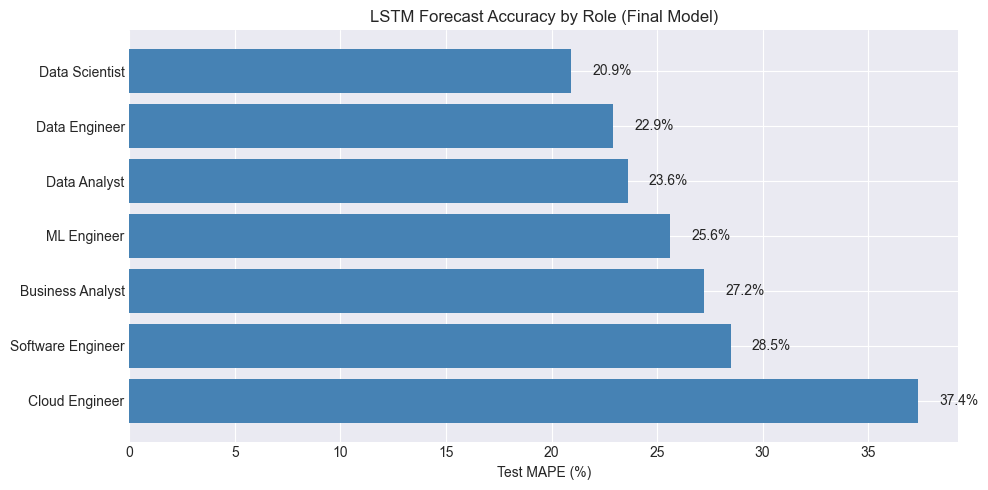

In [23]:
roles_new = ["Data Scientist", "Data Engineer", "Data Analyst", 
             "ML Engineer", "Business Analyst", "Software Engineer", "Cloud Engineer"]
mape_new = [20.94, 22.93, 23.61, 25.63, 27.23, 28.50, 37.39]

plt.figure(figsize=(10,5))
plt.barh(roles_new, mape_new, color='steelblue')
plt.xlabel("Test MAPE (%)")
plt.title("LSTM Forecast Accuracy by Role (Final Model)")
plt.gca().invert_yaxis()
for i, v in enumerate(mape_new):
    plt.text(v + 1, i, f"{v:.1f}%", va='center')
plt.tight_layout()
plt.savefig("models/final_mape_chart.png", dpi=150)
plt.show()

In [24]:

import os
import ast
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from scipy.sparse import lil_matrix, save_npz
import joblib
from tensorflow.keras.models import load_model

# Make sure skills are parsed
if "skills_list" not in df_all.columns:
    def parse_skills(skill_str):
        if pd.isna(skill_str):
            return []
        try:
            return ast.literal_eval(skill_str)
        except:
            return []
    df_all["skills_list"] = df_all["job_skills"].apply(parse_skills)

# Filter rows with non‑empty skills
df_with_skills = df_all[df_all["skills_list"].map(len) > 0].copy()
print(f"Rows with skills: {len(df_with_skills)} / {len(df_all)} ({100*len(df_with_skills)/len(df_all):.1f}%)")

Rows with skills: 410025 / 478895 (85.6%)


In [25]:
# Global skill frequencies (top 500)
all_skills = [skill for sublist in df_with_skills["skills_list"] for skill in sublist]
global_counts = Counter(all_skills)
global_df = pd.DataFrame(global_counts.items(), columns=["skill", "count"])
global_df["frequency_pct"] = 100 * global_df["count"] / len(df_with_skills)
global_df = global_df.sort_values("count", ascending=False).reset_index(drop=True)
global_df.head(500).to_csv("data/skills_global.csv", index=False)
print("Saved global skill frequencies to data/skills_global.csv")

# Per‑role skill frequencies (top 100 per role)
roles = df_all["job_title_short"].unique()
for role in roles:
    role_df = df_with_skills[df_with_skills["job_title_short"] == role]
    if len(role_df) == 0:
        continue
    role_skills = [skill for sublist in role_df["skills_list"] for skill in sublist]
    role_counts = Counter(role_skills)
    role_freq = pd.DataFrame(role_counts.items(), columns=["skill", "count"])
    role_freq["frequency_pct"] = 100 * role_freq["count"] / len(role_df)
    role_freq = role_freq.sort_values("count", ascending=False).head(100)
    safe_name = role.replace(" ", "_")
    role_freq.to_csv(f"data/skills_{safe_name}.csv", index=False)
    print(f"Saved {role} skills to data/skills_{safe_name}.csv")

Saved global skill frequencies to data/skills_global.csv
Saved Data Analyst skills to data/skills_Data_Analyst.csv
Saved Data Scientist skills to data/skills_Data_Scientist.csv
Saved Senior Data Scientist skills to data/skills_Senior_Data_Scientist.csv
Saved Machine Learning Engineer skills to data/skills_Machine_Learning_Engineer.csv
Saved Senior Data Analyst skills to data/skills_Senior_Data_Analyst.csv
Saved Data Engineer skills to data/skills_Data_Engineer.csv
Saved Software Engineer skills to data/skills_Software_Engineer.csv
Saved Business Analyst skills to data/skills_Business_Analyst.csv
Saved Senior Data Engineer skills to data/skills_Senior_Data_Engineer.csv
Saved Cloud Engineer skills to data/skills_Cloud_Engineer.csv


In [26]:
# Lookback dictionary (from your training config)
optimal_lookback = {
    "Data Analyst": 14,
    "Business Analyst": 14,
    "Software Engineer": 112,
    "Cloud Engineer": 28,
    "Machine Learning Engineer": 112,
    "Data Scientist": 112,
    "Data Engineer": 112,
}
forecast_days = 30

def predict_future_demand(role, forecast_days=30):
    """Load saved model & scaler, forecast average daily demand."""
    lookback = optimal_lookback.get(role)
    if lookback is None:
        return np.nan
    safe_role = role.replace(" ", "_")
    model_path = f"models/lstm_{safe_role}.keras"
    scaler_path = f"models/scaler_{safe_role}.pkl"
    
    if not os.path.exists(model_path) or not os.path.exists(scaler_path):
        print(f"Model for {role} not found, skipping.")
        return np.nan
    
    model = load_model(model_path)
    scaler = joblib.load(scaler_path)
    
    # Prepare historical demand
    daily = prepare_daily_demand(df_all, role)
    demand = daily["demand"].values.astype(np.float32)
    demand_scaled = scaler.transform(demand.reshape(-1,1)).flatten()
    
    # Last lookback days as seed
    last_seq = demand_scaled[-lookback:].reshape(1, lookback, 1)
    preds_scaled = []
    current = last_seq.copy()
    for _ in range(forecast_days):
        p = model.predict(current, verbose=0)[0,0]
        preds_scaled.append(p)
        current = np.roll(current, -1, axis=1)
        current[0, -1, 0] = p
    
    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1,1)).flatten()
    return preds.mean()

# Compute demand scores
demand_scores = {}
for role in optimal_lookback.keys():
    avg_demand = predict_future_demand(role, forecast_days)
    demand_scores[role] = avg_demand
    print(f"{role:25s} : predicted avg daily demand = {avg_demand:.1f}")

# Save to CSV
demand_df = pd.DataFrame(list(demand_scores.items()), columns=["role", "predicted_avg_daily_demand"])
demand_df.to_csv("data/demand_scores.csv", index=False)
print("Saved demand scores to data/demand_scores.csv")

Data Analyst              : predicted avg daily demand = 413.6
Business Analyst          : predicted avg daily demand = 67.6
Software Engineer         : predicted avg daily demand = 42.8
Cloud Engineer            : predicted avg daily demand = 16.6
Machine Learning Engineer : predicted avg daily demand = 34.9
Data Scientist            : predicted avg daily demand = 170.3
Data Engineer             : predicted avg daily demand = 248.0
Saved demand scores to data/demand_scores.csv


In [27]:
# Use top 300 skills from global list to keep matrix manageable
top_n_skills = 300
top_skills_list = global_df.head(top_n_skills)["skill"].tolist()
skill_to_idx = {skill: i for i, skill in enumerate(top_skills_list)}
n_skills = len(top_skills_list)

# Sparse co‑occurrence matrix
cooc = lil_matrix((n_skills, n_skills), dtype=np.int32)

for skills in df_with_skills["skills_list"]:
    # Keep only skills that are in our top list
    indices = [skill_to_idx[s] for s in skills if s in skill_to_idx]
    for i in indices:
        for j in indices:
            if i != j:
                cooc[i, j] += 1

# Convert to CSR for efficient storage
from scipy.sparse import csr_matrix
cooc_csr = csr_matrix(cooc)
save_npz("data/cooccurrence.npz", cooc_csr)
print(f"Saved co‑occurrence matrix ({n_skills} skills) to data/cooccurrence.npz")

# Also save the skill list for later
pd.Series(top_skills_list).to_csv("data/skill_list.csv", index=False, header=["skill"])
print("Saved skill list to data/skill_list.csv")

Saved co‑occurrence matrix (248 skills) to data/cooccurrence.npz
Saved skill list to data/skill_list.csv


In [28]:
def load_skill_frequencies():
    """Load pre‑computed skill frequencies into memory."""
    role_skills = {}
    for role in roles:
        safe = role.replace(" ", "_")
        path = f"data/skills_{safe}.csv"
        if os.path.exists(path):
            role_skills[role] = pd.read_csv(path)
    global_skills = pd.read_csv("data/skills_global.csv")
    demand = pd.read_csv("data/demand_scores.csv")
    demand_dict = dict(zip(demand["role"], demand["predicted_avg_daily_demand"]))
    return role_skills, global_skills, demand_dict

role_skills_cache, global_skills_cache, demand_scores_cache = load_skill_frequencies()

# ---------- Mode A: Demand only ----------
def recommend_by_demand(top_k_roles=3, top_skills_per_role=5):
    """Recommend top skills from roles with highest predicted demand."""
    sorted_roles = sorted(demand_scores_cache.items(), key=lambda x: x[1], reverse=True)
    top_roles = [r for r, _ in sorted_roles[:top_k_roles]]
    recs = []
    for role in top_roles:
        skills = role_skills_cache[role].head(top_skills_per_role)
        for _, row in skills.iterrows():
            recs.append({
                "skill": row["skill"],
                "source_role": role,
                "frequency_pct": row["frequency_pct"],
                "demand_score": demand_scores_cache[role]
            })
    return pd.DataFrame(recs)

# ---------- Mode B: Demand + user skills ----------
def recommend_by_demand_and_user(user_skills, top_k_roles=3, top_skills_per_role=5):
    """Recommend missing skills from high‑demand roles."""
    sorted_roles = sorted(demand_scores_cache.items(), key=lambda x: x[1], reverse=True)
    top_roles = [r for r, _ in sorted_roles[:top_k_roles]]
    user_lower = set(s.lower() for s in user_skills)
    recs = []
    for role in top_roles:
        skills_df = role_skills_cache[role]
        skills_df["skill_lower"] = skills_df["skill"].str.lower()
        missing = skills_df[~skills_df["skill_lower"].isin(user_lower)].head(top_skills_per_role)
        for _, row in missing.iterrows():
            recs.append({
                "skill": row["skill"],
                "source_role": role,
                "frequency_pct": row["frequency_pct"],
                "demand_score": demand_scores_cache[role]
            })
    return pd.DataFrame(recs)

# ---------- Mode C: Role‑specific + demand trend ----------
def recommend_with_trend(user_skills, target_role, top_k=5):
    """Weight skill frequencies by demand trend (predicted / historical)."""
    # Historical average (last 30 days of 2024)
    daily = prepare_daily_demand(df_all, target_role)
    hist_demand = daily["demand"].values[-30:].mean()
    pred_demand = demand_scores_cache.get(target_role, hist_demand)
    trend_factor = pred_demand / hist_demand if hist_demand > 0 else 1.0
    
    skills_df = role_skills_cache[target_role].copy()
    skills_df["weighted_score"] = skills_df["frequency_pct"] * trend_factor
    user_lower = set(s.lower() for s in user_skills)
    skills_df["skill_lower"] = skills_df["skill"].str.lower()
    missing = skills_df[~skills_df["skill_lower"].isin(user_lower)]
    missing = missing.sort_values("weighted_score", ascending=False).head(top_k)
    return missing[["skill", "frequency_pct", "weighted_score"]]

# ---------- Mode D: Skill‑to‑skill (co‑occurrence) ----------
def recommend_next_skills(user_skills, top_k=5):
    """Given a list of skills, recommend other skills that often appear together."""
    # Load co‑occurrence matrix and skill list
    from scipy.sparse import load_npz
    cooc = load_npz("data/cooccurrence.npz")
    skill_list = pd.read_csv("data/skill_list.csv")["skill"].tolist()
    skill_to_idx = {s: i for i, s in enumerate(skill_list)}
    
    user_lower = set(s.lower() for s in user_skills)
    # Map user skills to indices (only those in our top list)
    user_indices = [skill_to_idx[s] for s in user_skills if s in skill_to_idx]
    if not user_indices:
        return pd.DataFrame(columns=["skill", "cooccurrence_score"])
    
    # Sum co‑occurrence counts from all user skills
    total_cooc = np.zeros(len(skill_list))
    for idx in user_indices:
        total_cooc += cooc[idx].toarray().flatten()
    
    # Create recommendations (excluding skills already known)
    rec_indices = np.argsort(total_cooc)[::-1]
    recs = []
    for idx in rec_indices:
        skill = skill_list[idx]
        if skill.lower() not in user_lower:
            recs.append({"skill": skill, "cooccurrence_score": total_cooc[idx]})
        if len(recs) >= top_k:
            break
    return pd.DataFrame(recs)

# ---------- Mode E: Learning path (tiered skills for a role) ----------
def get_learning_path(target_role, tiers=[5, 10, 20]):
    """Return skill tiers (core, advanced, specialised) for a target role."""
    skills_df = role_skills_cache[target_role]
    path = {}
    prev = 0
    for i, tier_size in enumerate(tiers):
        tier_skills = skills_df.iloc[prev:prev+tier_size]["skill"].tolist()
        path[f"Tier {i+1}"] = tier_skills
        prev += tier_size
    return path

print("All recommendation modes are now defined.")

All recommendation modes are now defined.


In [29]:
# Example user skills
my_skills = ["python", "sql", "excel"]

print("\n" + "="*70)
print("MODE A: Demand‑only (top 2 roles, top 3 skills each)")
print(recommend_by_demand(top_k_roles=2, top_skills_per_role=3).to_string(index=False))

print("\n" + "="*70)
print("MODE B: Demand + my skills")
print(recommend_by_demand_and_user(my_skills, top_k_roles=2, top_skills_per_role=3).to_string(index=False))

print("\n" + "="*70)
print("MODE C: Role‑specific trend (Data Scientist)")
print(recommend_with_trend(my_skills, "Data Scientist", top_k=5).to_string(index=False))

print("\n" + "="*70)
print("MODE D: Skill‑to‑skill (next skills to learn)")
print(recommend_next_skills(my_skills, top_k=5).to_string(index=False))

print("\n" + "="*70)
print("MODE E: Learning path for Data Engineer")
path = get_learning_path("Data Engineer", tiers=[5,10,15])
for tier, skills in path.items():
    print(f"{tier}: {', '.join(skills)}")


MODE A: Demand‑only (top 2 roles, top 3 skills each)
 skill   source_role  frequency_pct  demand_score
   sql  Data Analyst      57.720637     413.58060
 excel  Data Analyst      41.451563     413.58060
python  Data Analyst      39.035223     413.58060
   sql Data Engineer      67.886017     248.03242
python Data Engineer      65.204408     248.03242
   aws Data Engineer      39.133164     248.03242

MODE B: Demand + my skills
   skill   source_role  frequency_pct  demand_score
 tableau  Data Analyst      29.615013     413.58060
power bi  Data Analyst      29.131305     413.58060
       r  Data Analyst      18.911877     413.58060
     aws Data Engineer      39.133164     248.03242
   azure Data Engineer      37.768182     248.03242
   spark Data Engineer      30.497044     248.03242

MODE C: Role‑specific trend (Data Scientist)
  skill  frequency_pct  weighted_score
      r      37.767803       38.349168
    aws      20.291156       20.603501
tableau      18.444741       18.728664
  

In [30]:
# ATS (CV Parser) – Skill Extraction & Role Matching

import PyPDF2
import docx
import re
from rapidfuzz import fuzz
import tempfile
import os

def extract_text_from_pdf(file_path):
    """Extract text from a PDF file."""
    text = ""
    with open(file_path, 'rb') as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            text += page.extract_text() + "\n"
    return text

def extract_text_from_docx(file_path):
    """Extract text from a DOCX file."""
    doc = docx.Document(file_path)
    text = "\n".join([para.text for para in doc.paragraphs])
    return text

def extract_text_from_txt(file_path):
    """Extract text from a TXT file."""
    with open(file_path, 'r', encoding='utf-8') as f:
        return f.read()

def extract_text(file_path):
    """Auto‑detect file type and extract text."""
    ext = os.path.splitext(file_path)[1].lower()
    if ext == '.pdf':
        return extract_text_from_pdf(file_path)
    elif ext == '.docx':
        return extract_text_from_docx(file_path)
    elif ext == '.txt':
        return extract_text_from_txt(file_path)
    else:
        raise ValueError(f"Unsupported file type: {ext}")

def extract_skills_from_text(text, skill_list, min_score=80):
    """
    Extract skills from text using fuzzy matching.
    Returns list of skills found.
    """
    text_lower = text.lower()
    found_skills = set()
    for skill in skill_list:
        # Exact match
        if skill.lower() in text_lower:
            found_skills.add(skill)
        else:
            # Fuzzy match for skill with spaces or slight variations
            words = text_lower.split()
            for word in words:
                if fuzz.ratio(skill.lower(), word) >= min_score:
                    found_skills.add(skill)
                    break
    return list(found_skills)

def ats_analyze_cv(file_path, target_role, top_n_missing=10):
    """
    Full ATS analysis:
    - Extract text from CV
    - Extract skills using global skill list
    - Compare against required skills for target role
    - Return match score, matched skills, missing skills (ranked by importance)
    """
    # Load global skill list (top 500 from pre‑computed data)
    global_skills_df = pd.read_csv("data/skills_global.csv")
    skill_list = global_skills_df.head(500)["skill"].tolist()
    
    # Load required skills for target role
    safe_role = target_role.replace(" ", "_")
    role_skills_path = f"data/skills_{safe_role}.csv"
    if not os.path.exists(role_skills_path):
        raise ValueError(f"Role '{target_role}' not found. Available roles: {os.listdir('data/')}")
    
    required_df = pd.read_csv(role_skills_path)
    # Use top N skills as "required" – e.g., top 30
    required_skills = required_df.head(30)["skill"].tolist()
    
    # Extract text from CV
    text = extract_text(file_path)
    
    # Extract skills from CV
    cv_skills = extract_skills_from_text(text, skill_list, min_score=85)
    
    # Calculate match
    matched = [s for s in required_skills if s in cv_skills]
    missing = [s for s in required_skills if s not in cv_skills]
    match_score = len(matched) / len(required_skills) * 100
    
    # Rank missing skills by importance (frequency in the role)
    missing_importance = []
    for skill in missing:
        freq = required_df[required_df["skill"] == skill]["frequency_pct"].values
        importance = freq[0] if len(freq) > 0 else 0
        missing_importance.append({"skill": skill, "importance_pct": importance})
    missing_importance = sorted(missing_importance, key=lambda x: x["importance_pct"], reverse=True)[:top_n_missing]
    
    return {
        "target_role": target_role,
        "match_score": round(match_score, 2),
        "matched_skills": matched,
        "missing_skills": missing_importance,
        "cv_skills_found": cv_skills[:20]  # show first 20 for debugging
    }

def print_ats_report(analysis):
    """Pretty print ATS analysis results."""
    print(f"\n{'='*60}")
    print(f"ATS Analysis for Role: {analysis['target_role']}")
    print(f"{'='*60}")
    print(f"Match Score: {analysis['match_score']:.1f}%")
    print(f"\n✅ Skills found in your CV: {', '.join(analysis['matched_skills'][:10])}")
    if len(analysis['matched_skills']) > 10:
        print(f"   ... and {len(analysis['matched_skills'])-10} more")
    
    print(f"\n❌ Missing skills (most important first):")
    for i, item in enumerate(analysis['missing_skills'], 1):
        print(f"   {i}. {item['skill']} (appears in {item['importance_pct']:.1f}% of {analysis['target_role']} postings)")
    
    print(f"\n🔍 Additional skills detected in your CV (not required):")
    extra = [s for s in analysis['cv_skills_found'] if s not in analysis['matched_skills']]
    print(f"   {', '.join(extra[:10])}" if extra else "   None")
    
    # Recommendation based on match score
    if analysis['match_score'] < 30:
        print("\n💡 Recommendation: You need to acquire most core skills. Start with the top 3 missing skills above.")
    elif analysis['match_score'] < 60:
        print("\n💡 Recommendation: Good foundation. Focus on the top missing skills to become competitive.")
    else:
        print("\n💡 Recommendation: You're a strong candidate! Consider applying or learning niche skills from the missing list.")

print("ATS functions ready. To test, save a CV file (PDF/DOCX/TXT) and run:")
print("result = ats_analyze_cv('path/to/your_cv.pdf', 'Data Scientist')")
print("print_ats_report(result)")

ATS functions ready. To test, save a CV file (PDF/DOCX/TXT) and run:
result = ats_analyze_cv('path/to/your_cv.pdf', 'Data Scientist')
print_ats_report(result)


In [31]:
# Quick test with dummy text
test_text = """
I have experience with Python, SQL, and Excel. 
I also know Tableau and Power BI for visualization.
My machine learning skills include scikit-learn and TensorFlow.
"""

# Create a temporary text file
with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
    f.write(test_text)
    temp_path = f.name

# Analyze for Data Scientist
result = ats_analyze_cv(temp_path, "Data Scientist")
print_ats_report(result)

# Clean up
os.unlink(temp_path)


ATS Analysis for Role: Data Scientist
Match Score: 26.7%

✅ Skills found in your CV: python, sql, r, tableau, tensorflow, power bi, excel, scikit-learn

❌ Missing skills (most important first):
   1. aws (appears in 20.3% of Data Scientist postings)
   2. azure (appears in 17.7% of Data Scientist postings)
   3. sas (appears in 15.9% of Data Scientist postings)
   4. spark (appears in 15.7% of Data Scientist postings)
   5. pytorch (appears in 12.7% of Data Scientist postings)
   6. pandas (appears in 10.6% of Data Scientist postings)
   7. hadoop (appears in 9.4% of Data Scientist postings)
   8. java (appears in 9.3% of Data Scientist postings)
   9. numpy (appears in 7.6% of Data Scientist postings)
   10. git (appears in 7.4% of Data Scientist postings)

🔍 Additional skills detected in your CV (not required):
   flow, c

💡 Recommendation: You need to acquire most core skills. Start with the top 3 missing skills above.


In [32]:
# Pre‑compute daily demand series and last lookback sequences
import os
os.makedirs("data/daily_demand", exist_ok=True)

optimal_lookback = {
    "Data Analyst": 14,
    "Business Analyst": 14,
    "Software Engineer": 112,
    "Cloud Engineer": 28,
    "Machine Learning Engineer": 112,
    "Data Scientist": 112,
    "Data Engineer": 112,
}

for role in optimal_lookback.keys():
    daily = prepare_daily_demand(df_all, role)
    # Save full daily demand (date, demand)
    daily.to_csv(f"data/daily_demand/{role.replace(' ', '_')}_daily.csv", index=False)
    print(f"Saved daily demand for {role}")
    
    # Also save the last `lookback` days of scaled demand for fast forecasting
    lookback = optimal_lookback[role]
    scaler = joblib.load(f"models/scaler_{role.replace(' ', '_')}.pkl")
    demand = daily["demand"].values.astype(np.float32)
    demand_scaled = scaler.transform(demand.reshape(-1,1)).flatten()
    last_seq = demand_scaled[-lookback:]
    np.save(f"data/daily_demand/{role.replace(' ', '_')}_last_seq.npy", last_seq)
    print(f"Saved last sequence for {role}")

Saved daily demand for Data Analyst
Saved last sequence for Data Analyst
Saved daily demand for Business Analyst
Saved last sequence for Business Analyst
Saved daily demand for Software Engineer
Saved last sequence for Software Engineer
Saved daily demand for Cloud Engineer
Saved last sequence for Cloud Engineer
Saved daily demand for Machine Learning Engineer
Saved last sequence for Machine Learning Engineer
Saved daily demand for Data Scientist
Saved last sequence for Data Scientist
Saved daily demand for Data Engineer
Saved last sequence for Data Engineer


In [33]:
# Pre‑compute 3‑month weekly forecasts (12 weeks)
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import joblib
from tensorflow.keras.models import load_model

optimal_lookback = {
    "Data Analyst": 14,
    "Business Analyst": 14,
    "Software Engineer": 112,
    "Cloud Engineer": 28,
    "Machine Learning Engineer": 112,
    "Data Scientist": 112,
    "Data Engineer": 112,
}

forecast_weeks = 12  # 3 months

weekly_forecasts = []

for role, lookback in optimal_lookback.items():
    print(f"Computing weekly forecast for {role}...")
    safe_role = role.replace(" ", "_")
    
    # Load model and scaler
    model = load_model(f"models/lstm_{safe_role}.keras")
    scaler = joblib.load(f"models/scaler_{safe_role}.pkl")
    
    # Prepare daily demand
    daily = prepare_daily_demand(df_all, role)
    demand = daily["demand"].values.astype(np.float32)
    demand_scaled = scaler.transform(demand.reshape(-1,1)).flatten()
    
    # Last lookback days as seed
    last_seq = demand_scaled[-lookback:].reshape(1, lookback, 1)
    
    # Forecast 12 weeks = 84 days (12 * 7)
    forecast_days = forecast_weeks * 7
    daily_forecasts_scaled = []
    current = last_seq.copy()
    for _ in range(forecast_days):
        pred_scaled = model.predict(current, verbose=0)[0,0]
        daily_forecasts_scaled.append(pred_scaled)
        current = np.roll(current, -1, axis=1)
        current[0, -1, 0] = pred_scaled
    
    daily_forecasts = scaler.inverse_transform(np.array(daily_forecasts_scaled).reshape(-1,1)).flatten()
    
    # Aggregate into weeks (7 days per week)
    weekly_avg = []
    for w in range(forecast_weeks):
        week_days = daily_forecasts[w*7 : (w+1)*7]
        avg = np.mean(week_days) if len(week_days) > 0 else 0
        weekly_avg.append(avg)
    
    # Normalise 0-100 across the 12 weeks for this role
    max_val = max(weekly_avg) if max(weekly_avg) > 0 else 1
    weekly_norm = [min(100, (val / max_val) * 100) for val in weekly_avg]
    
    for week_idx, norm_demand in enumerate(weekly_norm):
        weekly_forecasts.append({
            "role": role,
            "week": week_idx + 1,
            "demand": round(norm_demand, 2)
        })
    
    print(f"  Done for {role}")

# Save to CSV
forecast_df = pd.DataFrame(weekly_forecasts)
forecast_df.to_csv("data/weekly_forecasts.csv", index=False)
print("Saved weekly forecasts to data/weekly_forecasts.csv")

Computing weekly forecast for Data Analyst...
  Done for Data Analyst
Computing weekly forecast for Business Analyst...
  Done for Business Analyst
Computing weekly forecast for Software Engineer...
  Done for Software Engineer
Computing weekly forecast for Cloud Engineer...
  Done for Cloud Engineer
Computing weekly forecast for Machine Learning Engineer...
  Done for Machine Learning Engineer
Computing weekly forecast for Data Scientist...
  Done for Data Scientist
Computing weekly forecast for Data Engineer...
  Done for Data Engineer
Saved weekly forecasts to data/weekly_forecasts.csv
